### **Гипотеза:** Зная гендер испытуемого (0 = муж, 1 = жен), его гедоническую оценку запаха от -2 до +2 (далее Г.О.) и группу этого запаха, можно приблизтельно восстановить его активность головного мозга (в разбивке на 9 зон) на момент контакта с ним.

In [19]:
from pathlib import Path
import collections
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
from random import seed

from importer import *

In [20]:
PATH_ACTIVITY = Path('../DATA/activity/')
PATH_METAINFO = Path('../DATA/metainfo/name+type+ghedonic+gender.csv')
PATH_SPECTRAL = Path('../DATA/spectral/')

PATH_PROCDATA = Path('~hypothesis_processed')
CSV_PER_CAT = 3 # Первые два файла используем, третий просто выкидываем

### 1. Конвертируем данные EEG-Cutter в нужный формат

In [21]:
subjects = Path.iterdir(PATH_ACTIVITY)

for subject in subjects:
    if subject.is_dir():
        files = list(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        
        for (i, f) in enumerate(files):
            if i % CSV_PER_CAT != 2: # Каждрый ТРЕТИЙ файл
                if not (PATH_PROCDATA / subject.name / f.name).is_file():
                    convert_eegc_activity(f, (PATH_PROCDATA / subject.name / f.name))

Визуальный обзор для наглядности

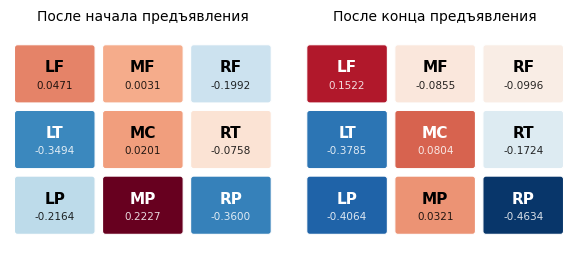

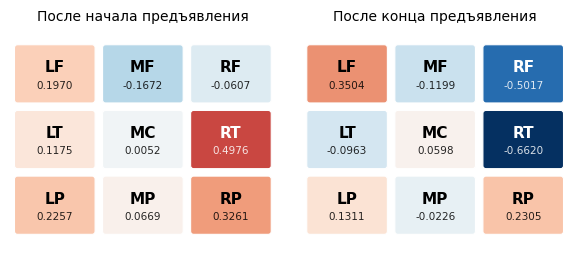

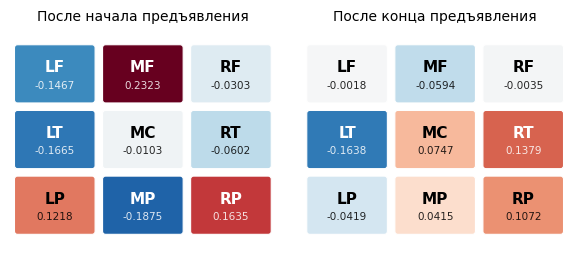

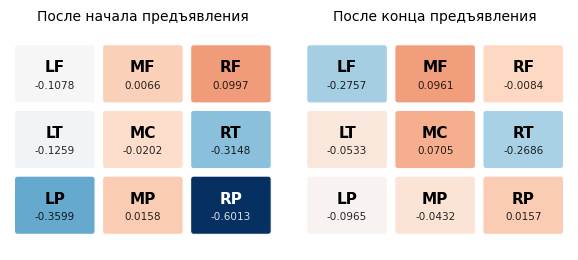

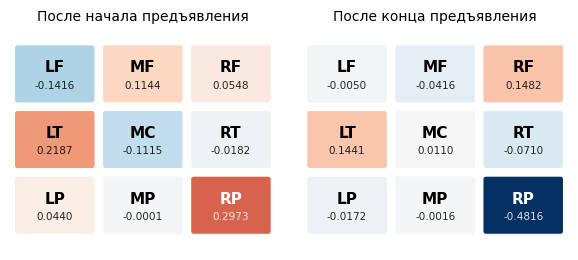

In [23]:
activites = list(Path.iterdir(PATH_PROCDATA / 'Bmet_007'))

for i in range(0, len(activites) - 2, (CSV_PER_CAT - 1)):
    vis_acitivty_by_zones(
        read_zone_activations(activites[i]),
        read_zone_activations(activites[i+1]),
        'После начала предъявления',
        'После конца предъявления'
    )

### 2. Делаем агрегацию с названиями, Г.О., гендером

In [24]:
metainfo = pd.read_csv(PATH_METAINFO)

metainfo

,subject,trial,scent_name,scent_type,ghedonic,gender
0,Bmet_001,1,Ладан,Древесные,1,1
1,Bmet_001,2,Розмарин,Хвойные,-1,1
2,Bmet_001,3,Чайное дерево,Хвойные,1,1
3,Bmet_001,4,Нероли,Цветочные,-1,1
4,Bmet_001,5,Майоран,Травянистые / Гурманские,-2,1
...,...,...,...,...,...,...
109,Met_013,2,Сладкий апельсин,Цитрусовые,1,1
110,Met_013,3,Герань,Цветочные,0,1
111,Met_013,4,Бергамот,Цитрусовые,2,1
112,Met_013,5,Лаванда,Цветочные,1,1


Немного статистики!

In [25]:
metainfo['scent_name'].value_counts()

scent_name
Лаванда              11
Эвкалипт              9
Бергамот              8
Герань                6
Ладан                 6
Сандал                6
Дикий апельсин        5
Лимон                 5
Корица                5
Перечная мята         4
Розмарин              3
Мелисса               3
Римская ромашка       3
Апельсин              3
Сибирская пихта       2
Ветивер               2
Зелёный мандарин      2
Грейпфрут             2
Чёрный перец          2
Садовая мята          1
Шёпот                 1
Куркума               1
Нероли                1
Чайное дерево         1
Кардамон              1
Иланг-иланг           1
Баланс                1
Кассия                1
Майоран               1
Кипарис               1
Герань                1
Дугласова пихта       1
Цитрус блюс           1
Фенхель               1
Базилик               1
Мирт                  1
Грушанка              1
Шалфей                1
Лимонный эвкалипт     1
Красный мандарин      1
Мята                  1
Кедр 

In [26]:
counts = collections.Counter()

for t, c in metainfo['scent_type'].value_counts().items():
    ts = str(t).split('/')
    
    for s in ts:
        ss = s.strip()
        counts[ss] += c

type_c = pd.Series(counts)

type_c.sort_values()

Землистые       2
Мятные          7
Гурманские     15
Травянистые    15
Древесные      17
Хвойные        20
Цветочные      23
Цитрусовые     29
dtype: int64

In [27]:
genders = metainfo['gender'].value_counts()

print(f'{genders[1] / (genders[0] + genders[1]) * 100} % испытуемых -- женщины!')

72.80701754385966 % испытуемых -- женщины!


Вернёмся обратно к агрегации

In [28]:
metainfo['scent_type_split'] = metainfo['scent_type'].apply(
    lambda ts: [t.strip() for t in ts.split('/')]
)

mlb = MultiLabelBinarizer()
groups = mlb.fit_transform(metainfo['scent_type_split'])

groups_df = pd.DataFrame(groups, columns=mlb.classes_)

dataset_input = pd.concat([
    metainfo['gender'],
    metainfo['ghedonic'].apply(lambda g: (g + 3.0) / 5.0),
    groups_df
], axis=1).astype('float32')

dataset_input

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,1.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
109,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
110,1.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
111,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
112,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [33]:
dataset_output_columns = []

for i in range(CSV_PER_CAT - 1):
    for zn in ZONE_NAMES:
        dataset_output_columns.append(f'{zn}_{i}')

dataset_output = pd.DataFrame(columns=dataset_output_columns).astype('float32')

subjects = Path.iterdir(PATH_ACTIVITY)
iii = 0

for subject in sorted(subjects):
    if subject.is_dir():
        files = list(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        
        for file in sorted(files):
            # Пропускаем файлы, которых нет в директории обработанных
            if (PATH_PROCDATA / subject.name / file.name).is_file():
                acts = read_zone_activations(PATH_PROCDATA / subject.name / file.name)

                for k, v in acts.items():
                    # if iii % (CSV_PER_CAT - 1) != 0:
                    #     break

                    dataset_output.at[iii // (CSV_PER_CAT - 1), f'{k}_{iii % (CSV_PER_CAT - 1)}'] = v

                iii += 1

# activity_df = activity_df[activity_df.columns[activity_df.columns.str.endswith('_0')]]
dataset_output

,LF_0,MF_0,RF_0,LT_0,MC_0,RT_0,LP_0,MP_0,RP_0,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1
0,-0.395678,0.119252,-0.065677,-0.114105,0.009600,-0.010954,0.005693,0.064466,-0.034749,-0.145949,0.108267,0.086840,-0.017640,0.059707,0.081945,-0.095917,-0.079321,0.023102
1,-0.119271,0.070146,-0.008217,-0.025100,0.032569,0.176896,-0.045746,-0.135861,-0.098791,-0.247218,-0.038609,-0.025840,-0.035525,-0.011336,0.006334,0.022997,0.063724,-0.040529
2,0.145465,-0.016992,0.144319,0.103060,-0.041721,-0.085677,0.075078,-0.169137,0.115972,0.003939,-0.284964,-0.048582,0.017231,0.073191,0.083507,0.005698,0.039686,-0.031741
3,0.110029,0.051252,0.023267,0.081270,-0.096504,0.034365,0.030550,0.104774,-0.009980,0.143122,-0.302455,0.054277,0.042155,-0.023253,0.039266,-0.026903,-0.460407,0.014547
4,0.244239,-0.163383,0.325244,-0.001412,-0.050756,0.060670,0.090715,-0.206584,-0.037430,0.355381,-0.143183,0.301232,0.191183,-0.163509,0.141477,0.065651,-0.058124,-0.016807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,-0.084558,-0.075963,0.385227,0.133797,0.023300,-0.314364,0.171825,-0.047818,-0.337446,0.019665,-0.066190,0.018734,0.002012,-0.020287,-0.004422,-0.099561,-0.022070,-0.247817
110,-0.180564,-0.013691,-0.097953,-0.205180,-0.015786,-0.263400,-0.124468,-0.030703,-0.116371,0.392656,0.068956,-0.219675,-0.155154,-0.028106,0.618847,-0.204184,0.122998,-0.150142
111,0.300434,0.295165,-0.388637,-0.537212,0.013046,-0.033299,-0.066143,0.002835,-0.007220,0.199472,0.004682,0.063670,0.023750,-0.073764,0.086235,-0.147799,0.069371,0.165414
112,0.031401,0.083411,-0.278035,-0.144576,0.137150,-0.285081,0.551076,0.131456,-0.937787,0.252064,-0.038500,-0.016834,-0.252207,-0.046200,-0.044076,-0.057971,0.088478,-0.035536


In [34]:
assert(len(dataset_input) == len(dataset_output))

### 3. Пробуем обучить нейронную сеть

In [35]:
RANDOM_SEED = 666

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
seed(RANDOM_SEED)

In [36]:
train_input, test_input, train_output, test_output = train_test_split(
    dataset_input, dataset_output, test_size=0.33, random_state=RANDOM_SEED
)

In [40]:
train_input.head()

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
29,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,1.0,0.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53,1.0,0.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
83,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [41]:
test_input.head()

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
58,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0,1.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,1.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
101,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [42]:
train_input_t = torch.tensor(train_input.values, dtype=torch.float32)
train_output_t = torch.tensor(train_output.values, dtype=torch.float32)
test_input_t = torch.tensor(test_input.values, dtype=torch.float32)
test_output_t = torch.tensor(test_output.values, dtype=torch.float32)

Обойдёмся пока без изысков, обычная полносвязная модель:

In [43]:
DROPOUT_P = 0.2 # 0.2, 0.5, 0.8

class HypothesisModelV1(torch.nn.Module):
    def __init__(self):
        super(HypothesisModelV1, self).__init__()

        self.fc1 = torch.nn.Linear(10, 16) # = Гендер (1) + Г.О. (1) + Типы (8)
        self.do1 = torch.nn.Dropout(DROPOUT_P)
        self.fc2 = torch.nn.Linear(16, 12)
        self.do2 = torch.nn.Dropout(DROPOUT_P)
        self.out = torch.nn.Linear(12, dataset_output.shape[1]) # 9 зон по N кадров

    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.leaky_relu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return x

In [44]:
model = HypothesisModelV1()
criterion = torch.nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005) # 0.0002


best_loss = 99.99
best_e = -1

for e in range(999999999):
    model.train()
    optimizer.zero_grad()
    
    train_pred = model(train_input_t)
    train_loss = criterion(train_pred, train_output_t)
    
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(test_input_t)
        test_loss = criterion(test_pred, test_output_t)

        if test_loss.item() < best_loss:
            best_e = e
            best_loss = test_loss.item()

    if e % 200 == 0:
        print(f'Потери на train на эпохе {e} = {train_loss.item()}')
        print(f'Потери на test на эпохе {e} = {test_loss.item()}\n')

        if e - best_e >= 5000:
            print('Модель перестала учиться, this is the end...')
            print(f'Лучшая эпоха: {best_e} (потери на test: {best_loss})')
            break

Потери на train на эпохе 0 = 0.07940824329853058
Потери на test на эпохе 0 = 0.06525792926549911

Потери на train на эпохе 200 = 0.07326998561620712
Потери на test на эпохе 200 = 0.058220602571964264

Потери на train на эпохе 400 = 0.06681399047374725
Потери на test на эпохе 400 = 0.052821699529886246

Потери на train на эпохе 600 = 0.06272312253713608
Потери на test на эпохе 600 = 0.048617925494909286

Потери на train на эпохе 800 = 0.0598052516579628
Потери на test на эпохе 800 = 0.04531816393136978

Потери на train на эпохе 1000 = 0.05606318265199661
Потери на test на эпохе 1000 = 0.0427471362054348

Потери на train на эпохе 1200 = 0.053456857800483704
Потери на test на эпохе 1200 = 0.04082585498690605

Потери на train на эпохе 1400 = 0.0532916784286499
Потери на test на эпохе 1400 = 0.039519812911748886

Потери на train на эпохе 1600 = 0.05260400474071503
Потери на test на эпохе 1600 = 0.03855793923139572

Потери на train на эпохе 1800 = 0.05153845623135567
Потери на test на эпохе 

Смотрим на метрики... и...

In [45]:
model.eval()

with torch.no_grad():
    y_pred = model(test_input_t).numpy()
    y_true = test_output_t.numpy()

print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

R2 Score: -0.0587
MAE: 0.1243
RMSE: 0.1921


### **Вывод:** в текущей постановке задачи её решение через нейронные сети невозможно.

**При Dropout = 0.2 *(золотой стандарт дропаута)*:**
- Лучшая эпоха: 1561 (потери на test: 0.2697705328464508)
- R2 Score: -0.1058
- MAE: 0.1756
- RMSE: 0.5244

**При Dropout = 0.5 *(сомнительно, но окЭй)*:**
- Лучшая эпоха: 6318 (потери на test: 0.2685116698741913)
- R2 Score: -0.0471
- MAE: 0.1698
- RMSE: 0.5197

**При Dropout = 0.8 *(модель заболела Альцгеймером)*:**
- Лучшая эпоха: 2933 (потери на test: 0.26527923345565796)
- R2 Score: -0.0316
- MAE: 0.1663
- RMSE: 0.5190